Data Preparation

In [13]:
import pandas as pd

# #Read the Excel file
# df = pd.read_excel("Sales Records.csv.xlsx")

# #Save as CSV file
# df.to_csv("salesrecords.csv", index=False)
df=pd.read_csv("salesrecords.csv")

In [14]:
df.head(50)

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Sub-Saharan Africa,South Africa,Fruits,Offline,M,7/27/2012,443368995,7/28/2012,1593,9.33,6.92,14862.69,11023.56,3839.13
1,Middle East and North Africa,Morocco,Clothes,Online,M,9/14/2013,667593514,10/19/2013,4611,109.28,35.84,503890.08,165258.24,338631.84
2,Australia and Oceania,Papua New Guinea,Meat,Offline,M,5/15/2015,940995585,2015-04-06 00:00:00,360,421.89,364.69,151880.40,131288.40,20592.00
3,Sub-Saharan Africa,Djibouti,Clothes,Offline,H,5/17/2017,880811536,2017-02-07 00:00:00,562,109.28,35.84,61415.36,20142.08,41273.28
4,Europe,Slovakia,Beverages,Offline,L,10/26/2016,174590194,2016-04-12 00:00:00,3973,47.45,31.79,188518.85,126301.67,62217.18
5,Asia,Sri Lanka,Fruits,Online,L,2011-07-11 00:00:00,830192887,12/18/2011,1379,9.33,6.92,12866.07,9542.68,3323.39
6,Sub-Saharan Africa,Seychelles,Beverages,Online,M,1/18/2013,425793445,2/16/2013,597,47.45,31.79,28327.65,18978.63,9349.02
7,Sub-Saharan Africa,Tanzania,Beverages,Online,L,11/30/2016,659878194,1/16/2017,1476,47.45,31.79,70036.20,46922.04,23114.16
8,Sub-Saharan Africa,Ghana,Office Supplies,Online,L,3/23/2017,601245963,4/15/2017,896,651.21,524.96,583484.16,470364.16,113120.00
9,Sub-Saharan Africa,Tanzania,Cosmetics,Offline,L,5/23/2016,739008080,5/24/2016,7768,437.20,263.33,3396169.60,2045547.44,1350622.16


In [15]:
df.shape #this converted CSV file have 500000 rows and 14 columns

(500000, 14)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Region          500000 non-null  str    
 1   Country         500000 non-null  str    
 2   Item Type       500000 non-null  str    
 3   Sales Channel   500000 non-null  str    
 4   Order Priority  500000 non-null  str    
 5   Order Date      500000 non-null  str    
 6   Order ID        500000 non-null  int64  
 7   Ship Date       500000 non-null  str    
 8   Units Sold      500000 non-null  int64  
 9   Unit Price      500000 non-null  float64
 10  Unit Cost       500000 non-null  float64
 11  Total Revenue   500000 non-null  float64
 12  Total Cost      500000 non-null  float64
 13  Total Profit    500000 non-null  float64
dtypes: float64(5), int64(2), str(7)
memory usage: 85.4 MB


In [17]:
#Listing all column names and identify their data types:
numerical_cols = df.select_dtypes(include=["number"]).columns.tolist() 

categorical_cols = df.select_dtypes(
    include=["object", "category", "boolean"]
).columns.tolist(),

datetime_cols = df.select_dtypes(include=["datetime64"]).columns.tolist() 

print(f"Numerical Columns:\n{numerical_cols}\n")
print(f"Categorical Columns:\n{categorical_cols}\n")
print(f"Datetime Columns:\n{datetime_cols}\n")

Numerical Columns:
['Order ID', 'Units Sold', 'Unit Price', 'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit']

Categorical Columns:
(['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority', 'Order Date', 'Ship Date'],)

Datetime Columns:
[]



C:\Users\Alpha1\AppData\Local\Temp\ipykernel_20864\3745783394.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


Data Cleaning

1,Identify Missing Values

In [18]:
df.isnull().sum() 
#since there are no misisng values no need for treatment method for each column

Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64

In [19]:
date_columns = ['Order Date','Ship Date']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], format='mixed').dt.normalize()

In [42]:
df.info()

    # since there are no misisng values no need for treatment method for each column
             #NOTES(i dont see any null values but from checking the data from df.head(50) 
             #i can see the time is not mentioned in any of the rows)
    
    # Converted to datetime first and striped the time from datetimecolumn
    
    # I removed the time from these column beacuse it had no useful information and 
    # it avoids misleading analysis


<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Region          500000 non-null  str           
 1   Country         500000 non-null  str           
 2   Item Type       500000 non-null  str           
 3   Sales Channel   500000 non-null  str           
 4   Order Priority  500000 non-null  str           
 5   Order Date      500000 non-null  datetime64[us]
 6   Order ID        500000 non-null  int64         
 7   Ship Date       500000 non-null  datetime64[us]
 8   Units Sold      500000 non-null  int64         
 9   Unit Price      500000 non-null  float64       
 10  Unit Cost       500000 non-null  float64       
 11  Total Revenue   500000 non-null  float64       
 12  Total Cost      500000 non-null  float64       
 13  Total Profit    500000 non-null  float64       
dtypes: datetime64[us](2), float64(5), int64(2), str

2,Detect and Remove Duplicate Records :-

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
#Found no duplicate values 

Detect and Handle Outliers

In [43]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'Order ID': 0, 'Units Sold': 0, 'Unit Price': 0, 'Unit Cost': 0, 'Total Revenue': 33685, 'Total Cost': 48752, 'Total Profit': 20867}


In [24]:
#   No outliers in: Order ID, Units Sold, Unit Price, Unit Cost

#     Many outliers in:
#         Total Revenue → 33,685
#         Total Cost → 48,752
#         Total Profit → 20,867

#     This is very common in sales data because:
#         Some orders are very large bulk purchases.
#         Revenue and cost are calculated values, so they naturally spread widely.
#         Profit can vary heavily depending on big deals or expensive items.

#         we can transform or cap them only if building a model sensitive to extreme values 

Analysis and Insights 

In [44]:
df.columns

Index(['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
       'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
       'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit'],
      dtype='str')

Text(0.5, 0, 'Total Profit')

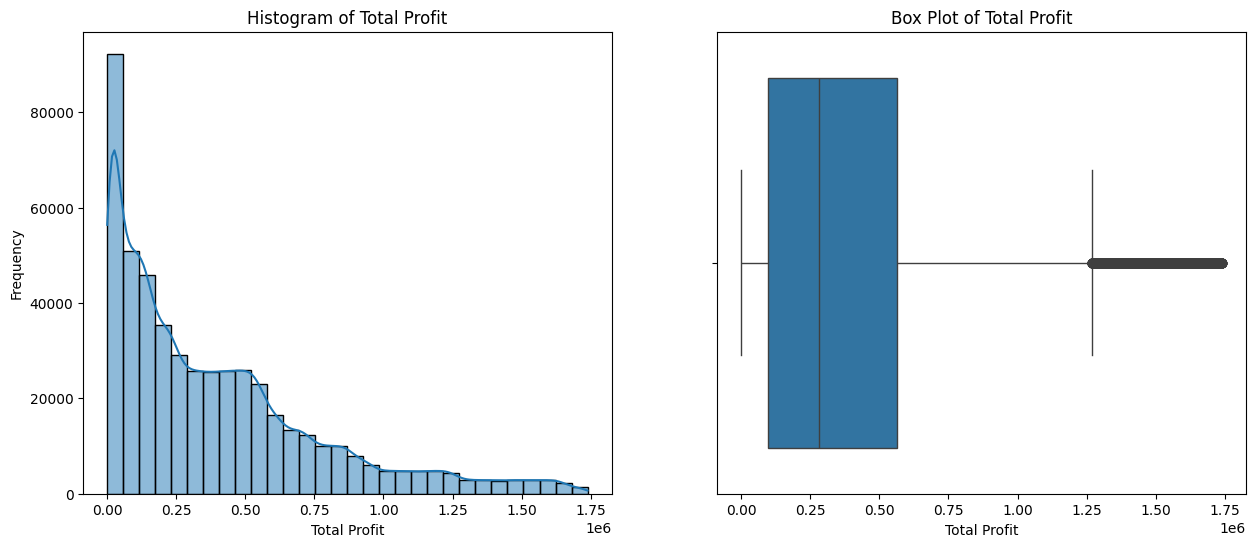

In [45]:
# Select the numerical column
import matplotlib.pyplot as plt
import seaborn as sns

column_to_analyze = 'Total Profit'

# Set up the matplotlib figure with two subplots (Histogram and Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#Histogram (To see shape, concentration, and skewness)
sns.histplot(df[column_to_analyze], bins=30, kde=True, ax=axes[0], )
axes[0].set_title(f'Histogram of {column_to_analyze}', )
axes[0].set_xlabel(column_to_analyze, )
axes[0].set_ylabel('Frequency', )

#Box Plot (To clearly see the median, quartiles, and outliers)
sns.boxplot(x=df[column_to_analyze], ax=axes[1],)
axes[1].set_title(f'Box Plot of {column_to_analyze}', )
axes[1].set_xlabel(column_to_analyze, )



In [27]:
print(f"Summary Statistics for {column_to_analyze}:")
print(df[column_to_analyze].describe())

Summary Statistics for Total Profit:
count    5.000000e+05
mean     3.924800e+05
std      3.787517e+05
min      2.410000e+00
25%      9.538506e+04
50%      2.817492e+05
75%      5.653923e+05
max      1.738700e+06
Name: Total Profit, dtype: float64


In [28]:
#The graph shows that while a typical 
# order makes around $245,000 the dataset is highly unpredictable, 
# featuring a few rare transactions that either made millions of dollars or
#  lost millions of dollars.

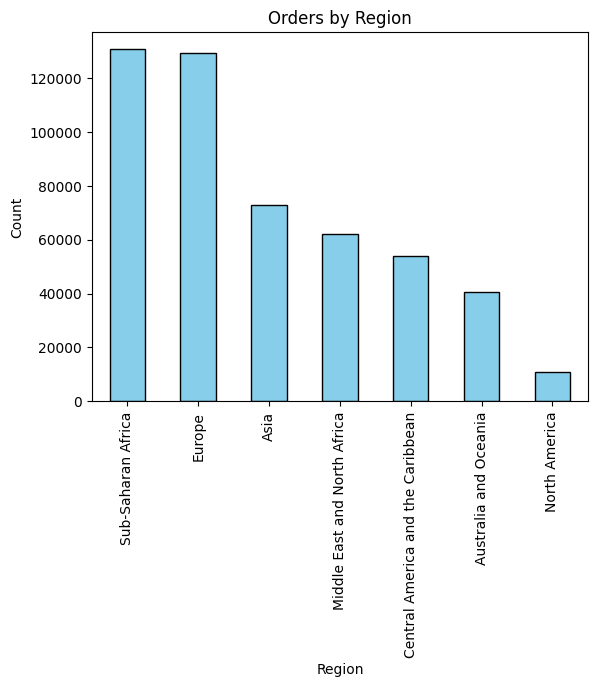

In [46]:
# Count the categories (this automatically sorts them)
counts = df['Region'].value_counts()

# Plot the bar chart
counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Add labels and display
plt.title('Orders by Region')
plt.xlabel('Region')
plt.ylabel('Count')

plt.show()

In [30]:
#performed bar chart in region and we can see that values doesnot vary too much 
#middle east and north africa have higest order count and cental america and the caribbean 
#have least count 

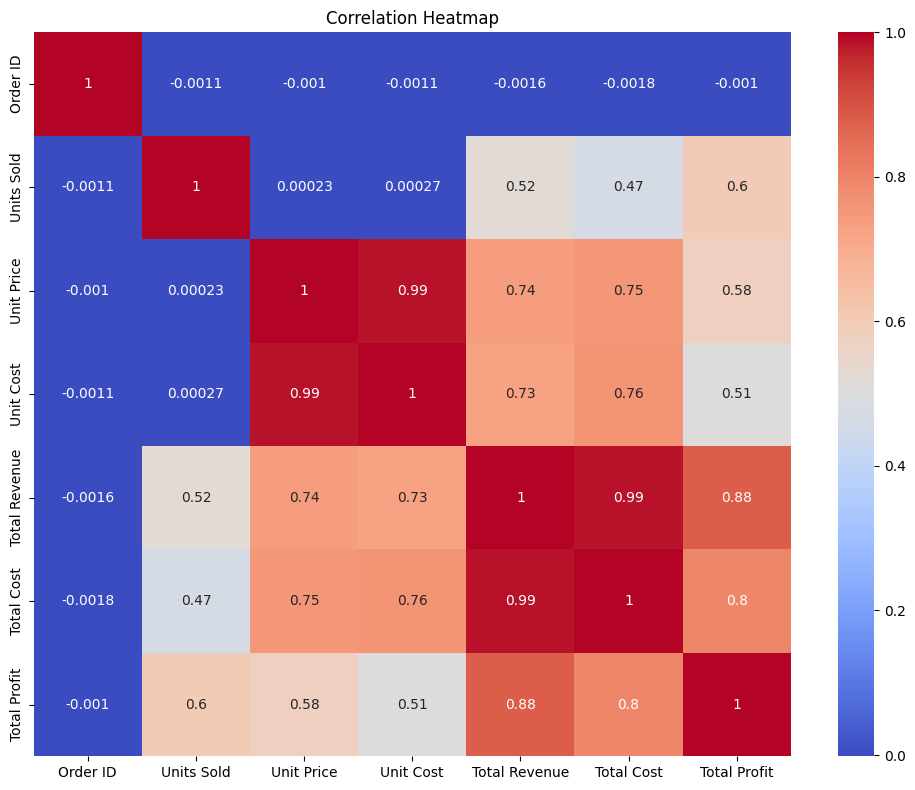

In [40]:
# Calculate the correlation matrix for numerical columns
numerical_corr = df.select_dtypes(include=['number']).corr()

# Create the heatmap plot
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_corr, annot=True, cmap='coolwarm', )

# Add a title and adjust layout
plt.title('Correlation Heatmap', )
plt.tight_layout()

plt.show()

In [ ]:
#taking total profit and total revenue , Correaltion = 0.88

# As Total Profit = Total Revenue - Total Cost So, 
# They go up and down together
# Total Revenue is all the money your business takes in from sales.

# Total Profit is the money you actually get to keep in your pocket.



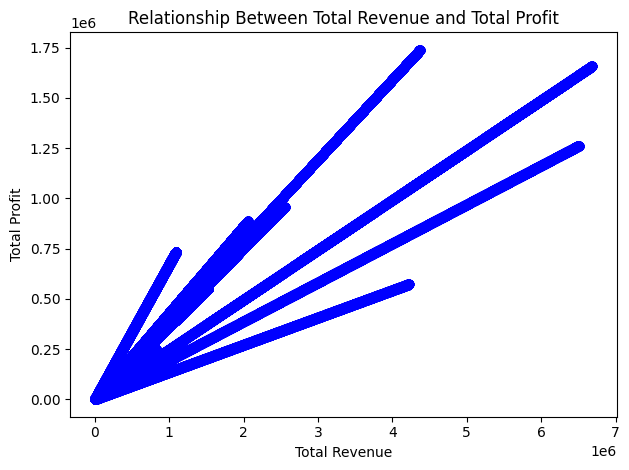

In [38]:
import matplotlib.pyplot as plt

# 1. Create the scatter plot
plt.scatter(df['Total Revenue'], df['Total Profit'], color='blue', alpha=0.5)

# 2. Add labels and a title
plt.title('Relationship Between Total Revenue and Total Profit')
plt.xlabel('Total Revenue')
plt.ylabel('Total Profit')
plt.tight_layout()  # Prevents labels from getting cut off

# 3. Display the plot
plt.show()

In [34]:
#Total Revenue is the total amount of money coming into the business from sales.
#  Total Profit is what is left over after you pay the costs. Because profit is 
# made directly from revenue, they move together in the same direction.
#the scatter plot shoes positive corelation with minimum outliers 

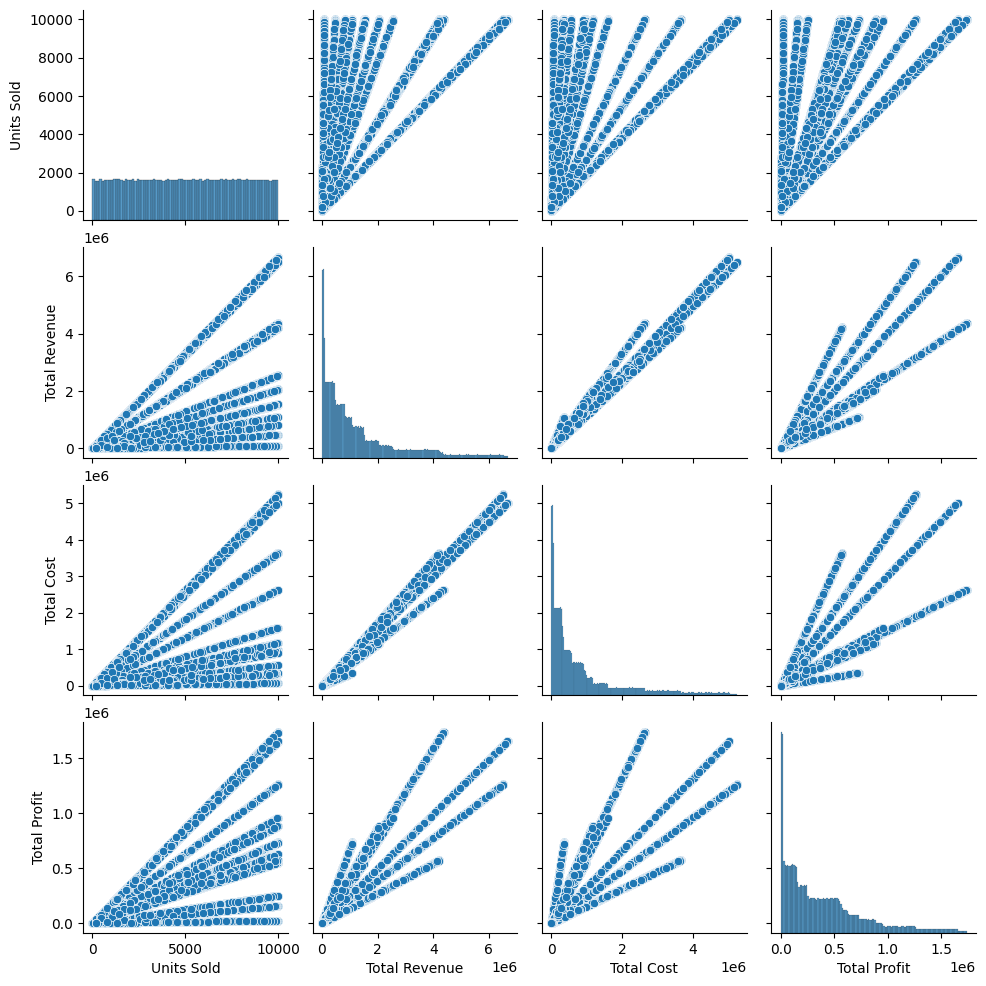

In [47]:
columns_to_plot = ['Units Sold', 'Total Revenue', 'Total Cost', 'Total Profit']

# 2. Create the pair plot
sns.pairplot(df[columns_to_plot])

# 3. Display the plot
plt.show()

In [ ]:
# The scatter plots show multiple straight-line patterns. This suggests the dataset contains
#  different product groups with different prices and costs. This insight is important because
#  it helps us understand that the data is made up of several segments rather than one single group,
#  which can improve analysis and machine learning models.


In [51]:
# This insight is incredibly useful because it tells you that 
# not all sales are equal. It explains why your business sometimes 
# makes millions of dollars and sometimes loses millions of dollars 
# on big orders. 

In [ ]:
# #Final Verdict 

# Following a Exploratory Data Analysis (EDA), the dataset proves to be highly viable for machine learning.
#  The clear relationships discovered—such as the strong positive correlation between Total Revenue and Total Profit, and
#  the varying profit margins across different product types—indicate that this data can be used to solve critical business problems

In [ ]:

# after analysis 
#  Proceed to build a Random Forest Regressor targeting Total Profit.
#  The dataset contains a  mix of operational scale indicators (Units Sold) and
#  categorical market vales (Region, Item Type). Because tree-based machine learning algorithms 
# naturally handle the sharp, non-linear financial spreads and extreme outliers discovered in the EDA phase,
#  a regression model will provide highly accurate, actionable forecasting for business strategy.